# Lead Scoring — RF & HGB Sweep × Concordance Thresholds

`composite = 2 × AUC_test + gap_pp` · Concordance ∈ {0.75, 0.80, 0.85, 0.90}


## 1 · Config & Imports


In [1]:
import re, json, os, sys, time, warnings, joblib
import numpy as np, pandas as pd
from itertools import product as iterproduct
from tqdm.auto import tqdm
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.tree import export_text
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt, matplotlib.patches as mpatches

sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")


/Users/Rohanchoudhary/Desktop/projs/genie_stocks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Run config ──
CONCORDANCE_THRESHOLDS = [0.75, 0.80, 0.85, 0.90]
N_RANDOM_SAMPLES       = 120
TEST_SIZE              = 0.30
RANDOM_STATE           = 42
FILL_VALUE             = -999
TARGET                 = "installed_decision"
RADIUS_M               = 100.0
K_MIN                  = 3
MODEL_DIR              = "../models/concordance_sweep"
os.makedirs(MODEL_DIR, exist_ok=True)


In [3]:
# ── Plot theme ──
plt.rcParams.update({
    "figure.facecolor": "#0a0e17", "axes.facecolor": "#111827",
    "axes.edgecolor": "#1e293b", "axes.labelcolor": "#9ca3af",
    "xtick.color": "#6b7280", "ytick.color": "#6b7280",
    "text.color": "#e2e8f0", "grid.color": "#1e293b",
    "font.family": "monospace", "font.size": 10,
})
AMBER, BLUE, GREEN  = "#f0b429", "#60a5fa", "#10b981"
RED, PURPLE, CYAN   = "#ef4444", "#a78bfa", "#22d3ee"
PINK, GRAY          = "#f472b6", "#4a5568"


## 2 · Data Load & Ops Merge


In [4]:
df_raw = pd.read_hdf("../reports/test_scored.h5", "df")
df_ops = pd.read_csv("../reports/partner_ops_train_vector.csv")
print(f"Scored: {df_raw.shape}  |  Ops: {df_ops.shape}")

# Detect temporal windows from ops columns
TEMPORAL_WINDOWS = sorted([
    int(c.replace("se_", "").replace("d", ""))
    for c in df_ops.columns if re.match(r"^se_\d+d$", c) and "delta" not in c
])
print(f"Temporal windows: {TEMPORAL_WINDOWS}")


Scored: (18082, 204)  |  Ops: (1475, 43)
Temporal windows: [30, 60, 365]


In [5]:
# Build ops column list
smallest_wd = min(TEMPORAL_WINDOWS)
rf_ops_cols = ["partner_id"]
for wd in TEMPORAL_WINDOWS:
    rf_ops_cols += [f"se_{wd}d", f"decline_rate_{wd}d", f"median_response_min_{wd}d"]
    if wd != smallest_wd:
        rf_ops_cols += [
            f"se_delta_{smallest_wd}_{wd}",
            f"decline_rate_delta_{smallest_wd}_{wd}",
            f"response_delta_{smallest_wd}_{wd}",
        ]
rf_ops_cols += [
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
]
rf_ops_cols = [c for c in rf_ops_cols if c in df_ops.columns]


In [6]:
# Merge ops onto scored data
df_raw["partner_id"] = df_raw["partner_id"].astype(str)
df_ops["partner_id"] = df_ops["partner_id"].astype(str)
df_raw = df_raw.merge(df_ops[rf_ops_cols], on="partner_id", how="left", suffixes=("", "_ops"))
df_raw = df_raw.loc[:, ~df_raw.columns.str.endswith("_ops")]
_ops_feature_cols = [c for c in rf_ops_cols if c != "partner_id"]
print(f"After ops merge: {df_raw.shape}  |  Ops cols: {len(_ops_feature_cols)}")


After ops merge: (18082, 223)  |  Ops cols: 19


## 3 · Feature Definition


In [7]:
FEATURES_SPATIAL = [
    "predicted_field_hex", "predicted_field_hex_all_wmean",
    "predicted_field_hex_all_kswmean", "predicted_field_hex_all_min",
    "predicted_field_hex_all_max", "predicted_field_hex_all_std",
    "n_overlapping_hexes_field", "total_sources_all_hexes", "contested_field",
    "predicted_field_hex_30d", "predicted_field_hex_60d",
    "predicted_field_hex_365d", "field_momentum",
]
FEATURES_HEX = [
    "parent_se", "parent_total", "parent_color_numeric",
    "n_covering_partners", "parent_overlap", "install_velocity",
    "weighted_se_30d_shrunk", "weighted_se_60d_shrunk",
    "weighted_se_365d_shrunk", "se_momentum",
]
FEATURES_HOP = [
    "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
    "hop1_se_std", "hop2_se_std", "hop3_se_std",
    "hop1_count", "hop2_count", "hop3_count",
    "se_gradient_1to3", "se_confirmed", "isolation_ratio",
]


In [8]:
FEATURES_TEMPORAL_HOP = [
    f"hop{h}_se_{w}d_wmean" for h in [1,2,3] for w in [30,60,365]
] + [
    f"se_gradient_1to3_{w}d" for w in [30,60,365]
] + [
    f"se_confirmed_{w}d" for w in [30,60,365]
]
FEATURES_CONTESTED = [
    "contested_area_km2", "contested_radius_m", "contested_se",
    "contested_se_30d", "contested_se_60d", "contested_se_365d",
    "n_overlapping_partners",
]
FEATURES_BOUNDARY = [
    "dist_to_boundary_edge_point_hex", "dist_to_cluster_center_point_hex",
    "depth_score_point_hex", "mean_dist_to_edge_m", "mean_dist_to_center_m",
    "total_area_boundaries", "nmbr_overlap_clusters",
    "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
    "worst_depth_score", "any_near_edge", "is_solo_cluster",
]


In [9]:
FEATURES_GEOMETRY = [
    "local_anisotropy", "local_density", "hull_area",
    "linearity_score", "spread_m", "dense_score", "gully_score", "sparse_score",
] + [
    f"{m}_{w}d" for m in ["local_density","dense_score","sparse_score","spread_m"]
    for w in [30,60,365]
]
FEATURES_LEAD = ["hard_density", "density_regime", "min_dist"]

FEATURES = (
    FEATURES_SPATIAL + FEATURES_HEX + FEATURES_HOP + FEATURES_TEMPORAL_HOP
    + FEATURES_CONTESTED + FEATURES_BOUNDARY + FEATURES_GEOMETRY
    + FEATURES_LEAD + _ops_feature_cols
)
available = [f for f in FEATURES if f in df_raw.columns]
missing   = [f for f in FEATURES if f not in df_raw.columns]
print(f"Features: {len(available)}/{len(FEATURES)} available, {len(missing)} missing")


Features: 111/111 available, 0 missing


## 4 · Concordance-Gated Label Cleaning


In [10]:
from data_lib.data_fetch.get_data import get_test_data
import data_lib.config as config

df_test_raw = get_test_data(config.TEST_START_DATE, config.TEST_END_DATE)
mobile_decisions = df_test_raw.groupby("mobile")["final_decision"].first()
hard_mobiles = mobile_decisions[mobile_decisions.isin(["INSTALLED","DECLINED"])].index
ambig_mobiles = mobile_decisions[mobile_decisions.isin(["INDETERMINATE","HANGING"])].index
print(f"Hard: {len(hard_mobiles)}  |  Ambiguous: {len(ambig_mobiles)}")


Fetching TEST data (2025-10-20 to 2025-11-09)...
[WiomData] snowflake_select_start: select partner_id, mobile, first_notified_time,
               case when lco_account_installed = par
Standardization Cutoff (p40): 288.63 minutes
STANDARDISED DECISIONS (TRAIN):
final_decision
DECLINED         12334
INSTALLED        10477
INDETERMINATE     5635
HANGING           2697
Name: count, dtype: int64
Hard: 13249  |  Ambiguous: 4323


In [11]:
# Build BallTree on hard training decisions
df_train_h5 = pd.read_hdf("../artifacts/train_data.h5", "df")
hard_train = df_train_h5[df_train_h5["final_decision"].isin(["INSTALLED","DECLINED"])].copy()
hard_train["is_install"] = (hard_train["final_decision"] == "INSTALLED").astype(int)

train_rad = np.radians(hard_train[["latitude","longitude"]].values)
train_labels = hard_train["is_install"].values
ball_tree = BallTree(train_rad, metric="haversine")

# Query ambiguous leads once — reuse for all thresholds
ambig_in_df = df_raw[df_raw["mobile"].isin(ambig_mobiles)].copy()
radius_rad = RADIUS_M / 6_371_000
ambig_rad = np.radians(ambig_in_df[["latitude","longitude"]].values)
idx_list, _ = ball_tree.query_radius(ambig_rad, r=radius_rad, return_distance=True)
print(f"Ambiguous in scored_df: {len(ambig_in_df)}")


Ambiguous in scored_df: 4578


In [12]:
def filter_by_concordance(conc_thresh):
    """Return filtered df for a given concordance threshold."""
    keep_mask = []
    for idxs in idx_list:
        if len(idxs) < K_MIN:
            keep_mask.append(False)
            continue
        frac_pos = train_labels[idxs].mean()
        keep_mask.append(max(frac_pos, 1 - frac_pos) >= conc_thresh)
    keep_mask = np.array(keep_mask)
    concordant = ambig_in_df.loc[keep_mask, "mobile"].values
    keep = set(hard_mobiles) | set(concordant)
    df_filt = df_raw[df_raw["mobile"].isin(keep)].copy()
    n_ambig = len(concordant)
    return df_filt, n_ambig


## 5 · Evaluation Utilities

`composite = 2 × AUC_test + gap_pp`


In [13]:
def eval_model(model, X_tr, y_tr, X_te, y_te):
    """Fit metrics + decile SE. composite = 200*auc_test + gap_pp."""
    
    p_train = model.predict(X_tr)
    p_test  = model.predict(X_te)

    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    edf = pd.DataFrame({"y": y_te.values, "p": p_test})

    # deciles
    edf["decile"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1

    tbl = (
        edf.groupby("decile")
        .agg(n=("y","count"), inst=("y","sum"))
        .reindex(range(1,11))   # ensure 1..10 exist
    )

    tbl["se"] = tbl["inst"] / tbl["n"]

    d1_se  = tbl.loc[1, "se"]
    d10_se = tbl.loc[10, "se"]

    gap_pp = (d10_se - d1_se) * 100
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())
    composite = 200 * auc_test + gap_pp

    result = dict(
        auc_train=round(auc_train,4),
        auc_test=round(auc_test,4),
        gap_pp=round(gap_pp,2),
        d1_se=round(d1_se,4),
        d10_se=round(d10_se,4),
        mono=mono,
        composite=round(composite,2),
    )

    # write ALL deciles
    for i in range(1, 11):
        result[f"d{i}_se"] = round(tbl.loc[i, "se"], 4) if pd.notna(tbl.loc[i, "se"]) else None
        result[f"d{i}_n"]  = int(tbl.loc[i, "n"]) if pd.notna(tbl.loc[i, "n"]) else 0

    return result

## 6 · Hyperparameter Grids


In [14]:
RF_GRID = {
    "n_estimators":     [200, 300, 500],
    "max_depth":        [6, 8, 12, 16, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_features":     ["sqrt", 0.3, 0.5],
}
HGB_GRID = {
    "learning_rate":     [0.02, 0.04, 0.07, 0.10],
    "max_depth":         [3, 4, 6, 8],
    "min_samples_leaf":  [30, 50, 100, 200],
    "l2_regularization": [0.5, 2.0, 5.0, 10.0],
    "max_leaf_nodes":    [15, 31, 63],
}
HGB_FIXED = dict(
    loss="squared_error", max_iter=1000, max_bins=255,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=30, random_state=RANDOM_STATE,
)


In [15]:
# Pre-sample combos (same seed → reproducible across concordance thresholds)
np.random.seed(RANDOM_STATE)
all_rf  = list(iterproduct(*RF_GRID.values()))
all_hgb = list(iterproduct(*HGB_GRID.values()))
rf_idx  = np.random.choice(len(all_rf),  min(N_RANDOM_SAMPLES, len(all_rf)),  replace=False)
hgb_idx = np.random.choice(len(all_hgb), min(N_RANDOM_SAMPLES, len(all_hgb)), replace=False)
sampled_rf  = [all_rf[i]  for i in rf_idx]
sampled_hgb = [all_hgb[i] for i in hgb_idx]
print(f"RF: {len(all_rf)} → {len(sampled_rf)}  |  HGB: {len(all_hgb)} → {len(sampled_hgb)}")


RF: 180 → 120  |  HGB: 768 → 120


## 7 · Sweep Runner


In [16]:
def run_rf_sweep(X_tr, y_tr, X_te, y_te):
    """Run RF sweep, return (results_list, best_model)."""
    rows, best_comp, best_mdl = [], -np.inf, None
    for n_est, md, msl, mf in tqdm(sampled_rf, desc="RF"):
        m = RandomForestRegressor(
            n_estimators=n_est, max_depth=md, min_samples_leaf=msl,
            max_features=mf, random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(X_tr, y_tr)
        ev = eval_model(m, X_tr, y_tr, X_te, y_te)
        row = {"model":"RF", "params": json.dumps(
            {"n_estimators":n_est,"max_depth":md,"min_samples_leaf":msl,"max_features":mf}),
            **{k:ev[k] for k in ev if k!="decile_tbl"}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  RF new best: auc={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")

    return rows, best_mdl


In [17]:
def run_hgb_sweep(X_tr, y_tr, X_te, y_te):
    """Run HGB sweep, return (results_list, best_model)."""
    rows, best_comp, best_mdl = [], -np.inf, None
    for lr, md, msl, l2, mln in tqdm(sampled_hgb, desc="HGB"):
        m = HistGradientBoostingRegressor(
            learning_rate=lr, max_depth=md, min_samples_leaf=msl,
            l2_regularization=l2, max_leaf_nodes=mln, **HGB_FIXED)
        m.fit(X_tr, y_tr)
        ev = eval_model(m, X_tr, y_tr, X_te, y_te)
        row = {"model":"HGB", "params": json.dumps(
            {"learning_rate":lr,"max_depth":md,"min_samples_leaf":msl,
             "l2":l2,"max_leaf_nodes":mln,"n_iter":m.n_iter_}),
            **{k:ev[k] for k in ev if k!="decile_tbl"}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  HGB new best: auc={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")
    return rows, best_mdl


## 8 · Concordance Sweep Loop


In [20]:
for conc in CONCORDANCE_THRESHOLDS:
    print(f"\n{'='*70}")
    print(f"  CONCORDANCE = {conc}")
    print(f"{'='*70}")

    # ── split on FULL data first ──
    X_all = df_raw[available].fillna(FILL_VALUE)
    y_all = df_raw[TARGET]
    mask = y_all.notna()
    X_all, y_all = X_all[mask], y_all[mask]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y_all.astype(int))

    # ── concordance filter ONLY train ──
    df_c, n_ambig = filter_by_concordance(conc)
    conc_idx = df_c.index.intersection(X_tr.index)
    X_tr, y_tr = X_tr.loc[conc_idx], y_tr.loc[conc_idx]

    print(f"  train={len(X_tr)} (filtered)  test={len(X_te)} (full)  ambig_added={n_ambig}")

    # ── sweeps (unchanged) ──
    rf_rows, best_rf = run_rf_sweep(X_tr, y_tr, X_te, y_te)
    for r in rf_rows: r["concordance"] = conc
    all_results.extend(rf_rows)

    hgb_rows, best_hgb = run_hgb_sweep(X_tr, y_tr, X_te, y_te)
    for r in hgb_rows: r["concordance"] = conc
    all_results.extend(hgb_rows)

    for tag, mdl in [("RF", best_rf), ("HGB", best_hgb)]:
        path = f"{MODEL_DIR}/{tag}_conc{conc:.2f}.joblib"
        joblib.dump(mdl, path)
        saved_models[(conc, tag)] = path
        print(f"  saved {path}")


  CONCORDANCE = 0.75
  train=10888 (filtered)  test=5425 (full)  ambig_added=2033


RF:   1%|          | 1/120 [00:01<03:13,  1.63s/it]

  RF new best: auc=0.6819 gap=55.99 comp=192.37


RF:   2%|▏         | 2/120 [00:02<02:03,  1.04s/it]

  RF new best: auc=0.6809 gap=57.09 comp=193.26


...

  HGB new best: auc=0.6891 gap=55.58 comp=193.41


HGB:  34%|███▍      | 41/120 [00:24<00:59,  1.33it/s]

  HGB new best: auc=0.6895 gap=58.01 comp=195.91


HGB: 100%|██████████| 120/120 [01:14<00:00,  1.61it/s]

  saved ../models/concordance_sweep/RF_conc0.90.joblib
  saved ../models/concordance_sweep/HGB_conc0.90.joblib


## 9 · Combined Leaderboard


In [21]:
df_train_h5.shape

(721722, 18)

In [22]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("composite", ascending=False).reset_index(drop=True)

metric_cols = ["concordance","model","params","auc_train","auc_test",
               "gap_pp","d1_se","d10_se","mono","composite"]
decile_cols = [f"d{d}_se" for d in range(1,11)] + [f"d{d}_n" for d in range(1,11)]
report_cols = [c for c in metric_cols + decile_cols if c in results_df.columns]

results_df[report_cols].to_csv("../reports/concordance_sweep_report.csv", index=False)
print(f"Saved {len(results_df)} rows to concordance_sweep_report.csv")


Saved 960 rows to concordance_sweep_report.csv


In [23]:
# Top 10 per concordance threshold
for conc in CONCORDANCE_THRESHOLDS:
    sub = results_df[results_df["concordance"]==conc].head(10)
    print(f"\n── C={conc} top 10 ──")
    print(sub[["model","auc_test","gap_pp","composite","mono","params"]].to_string(index=False))



── C=0.75 top 10 ──
model  auc_test  gap_pp  composite  mono                                                                                                          params
   RF    0.6900   61.88     199.88  True                          {"n_estimators": 200, "max_depth": 16, "min_samples_leaf": 20, "max_features": "sqrt"}
   RF    0.6900   61.69     199.70  True                          {"n_estimators": 300, "max_depth": 16, "min_samples_leaf": 20, "max_features": "sqrt"}
  HGB    0.6896   61.29     199.22 False {"learning_rate": 0.02, "max_depth": 8, "min_samples_leaf": 50, "l2": 0.5, "max_leaf_nodes": 63, "n_iter": 297}
   RF    0.6925   60.59     199.08 False                             {"n_estimators": 300, "max_depth": 12, "min_samples_leaf": 20, "max_features": 0.5}
   RF    0.6894   60.96     198.84  True                          {"n_estimators": 300, "max_depth": 12, "min_samples_leaf": 20, "max_features": "sqrt"}
   RF    0.6899   60.77     198.76  True                     

## 10 · Concordance Comparison


In [24]:
summary = (results_df.groupby(["concordance","model"])
    .agg(best_composite=("composite","max"), best_auc=("auc_test","max"),
         best_gap=("gap_pp","max"), median_composite=("composite","median"),
         n_mono=("mono","sum"), n_runs=("mono","count"))
    .reset_index())
summary["mono_pct"] = (summary["n_mono"] / summary["n_runs"] * 100).round(1)
print(summary.to_string(index=False))


 concordance model  best_composite  best_auc  best_gap  median_composite  n_mono  n_runs  mono_pct
        0.75   HGB          199.22    0.6909     61.29           194.210      73     120      60.8
        0.75    RF          199.88    0.6925     61.88           193.230      97     120      80.8
        0.80   HGB          199.88    0.6930     61.69           195.620      82     120      68.3
        0.80    RF          200.11    0.6951     61.51           193.675      66     120      55.0
        0.85   HGB          200.91    0.6970     61.51           194.265      67     120      55.8
        0.85    RF          194.15    0.6916     56.17           186.190      71     120      59.2
        0.90   HGB          195.91    0.6895     58.01           188.935      82     120      68.3
        0.90    RF          194.21    0.6908     56.54           187.320      41     120      34.2


## 11 · Best-Model Deep Dive


In [25]:
# Pick overall best concordance + model
best_row = results_df.iloc[0]
best_conc = best_row["concordance"]
best_type = best_row["model"]
best_path = saved_models[(best_conc, best_type)]
best_model = joblib.load(best_path)
print(f"Best: {best_type} @ concordance={best_conc}  composite={best_row['composite']}")
print(f"  AUC={best_row['auc_test']}  gap_pp={best_row['gap_pp']}  mono={best_row['mono']}")
print(f"  params: {best_row['params']}")


Best: HGB @ concordance=0.85  composite=200.91
  AUC=0.697  gap_pp=61.51  mono=True
  params: {"learning_rate": 0.1, "max_depth": 8, "min_samples_leaf": 50, "l2": 5.0, "max_leaf_nodes": 63, "n_iter": 73}


In [26]:
# Rebuild test set for best concordance
df_best, _ = filter_by_concordance(best_conc)
X_b = df_best[available].fillna(FILL_VALUE)
y_b = df_best[TARGET]
mask = y_b.notna()
X_b, y_b = X_b[mask], y_b[mask]
_, X_te_b, _, y_te_b = train_test_split(
    X_b, y_b, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_b.astype(int))
p_best = best_model.predict(X_te_b)


### 11a · Decile & ROC Curves


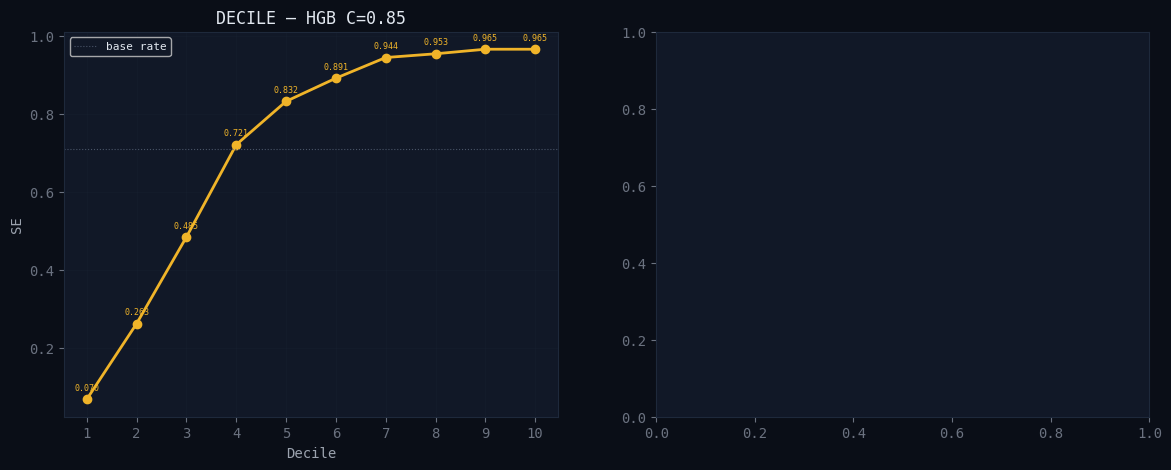

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decile curve
ax = axes[0]
edf = pd.DataFrame({"y": y_te_b.values, "p": p_best})
edf["d"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
tbl = edf.groupby("d").agg(n=("y","count"), inst=("y","sum"))
tbl["se"] = tbl["inst"] / tbl["n"]
d_range = list(range(1, len(tbl)+1))
ax.plot(d_range, tbl["se"].values, "o-", color=AMBER, lw=2, ms=6)
for j, se in enumerate(tbl["se"].values):
    ax.annotate(f"{se:.3f}", (j+1, se), fontsize=6, ha="center",
                va="bottom", xytext=(0,5), textcoords="offset points", color=AMBER)
ax.axhline(y_te_b.mean(), color=GRAY, ls=":", lw=0.8, label="base rate")
ax.set(xlabel="Decile", ylabel="SE", title=f"DECILE — {best_type} C={best_conc}")
ax.set_xticks(range(1,11)); ax.legend(fontsize=8); ax.grid(alpha=0.2)


In [28]:
# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_te_b, p_best)
roc_auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color=AMBER, lw=2, label=f"{best_type} AUC={roc_auc_val:.4f}")
ax.plot([0,1],[0,1],":", color=GRAY, lw=0.8)
ax.set(xlabel="FPR", ylabel="TPR", title=f"ROC — {best_type} C={best_conc}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


<Figure size 640x480 with 0 Axes>

### 11b · Feature Importance


In [29]:
# Family color map
_families = {
    "spatial": FEATURES_SPATIAL, "hex": FEATURES_HEX, "hop": FEATURES_HOP,
    "hop_temporal": FEATURES_TEMPORAL_HOP, "contested": FEATURES_CONTESTED,
    "boundary": FEATURES_BOUNDARY, "geometry": FEATURES_GEOMETRY,
    "lead": FEATURES_LEAD, "ops": _ops_feature_cols,
}
family_map = {f: fam for fam, feats in _families.items() for f in feats}
fam_colors = {
    "spatial": AMBER, "hex": BLUE, "hop": PURPLE, "hop_temporal": PURPLE,
    "contested": PINK, "boundary": CYAN, "geometry": GREEN,
    "lead": RED, "ops": "#ff6b6b",
}


In [30]:
# If best model is RF, plot feature importance directly; else load best RF
if best_type == "RF":
    imp_model = best_model
else:
    rf_path = saved_models[(best_conc, "RF")]
    imp_model = joblib.load(rf_path)

imp = pd.Series(imp_model.feature_importances_, index=available).sort_values(ascending=True)
colors = [fam_colors.get(family_map.get(f,""), GRAY) for f in imp.index]


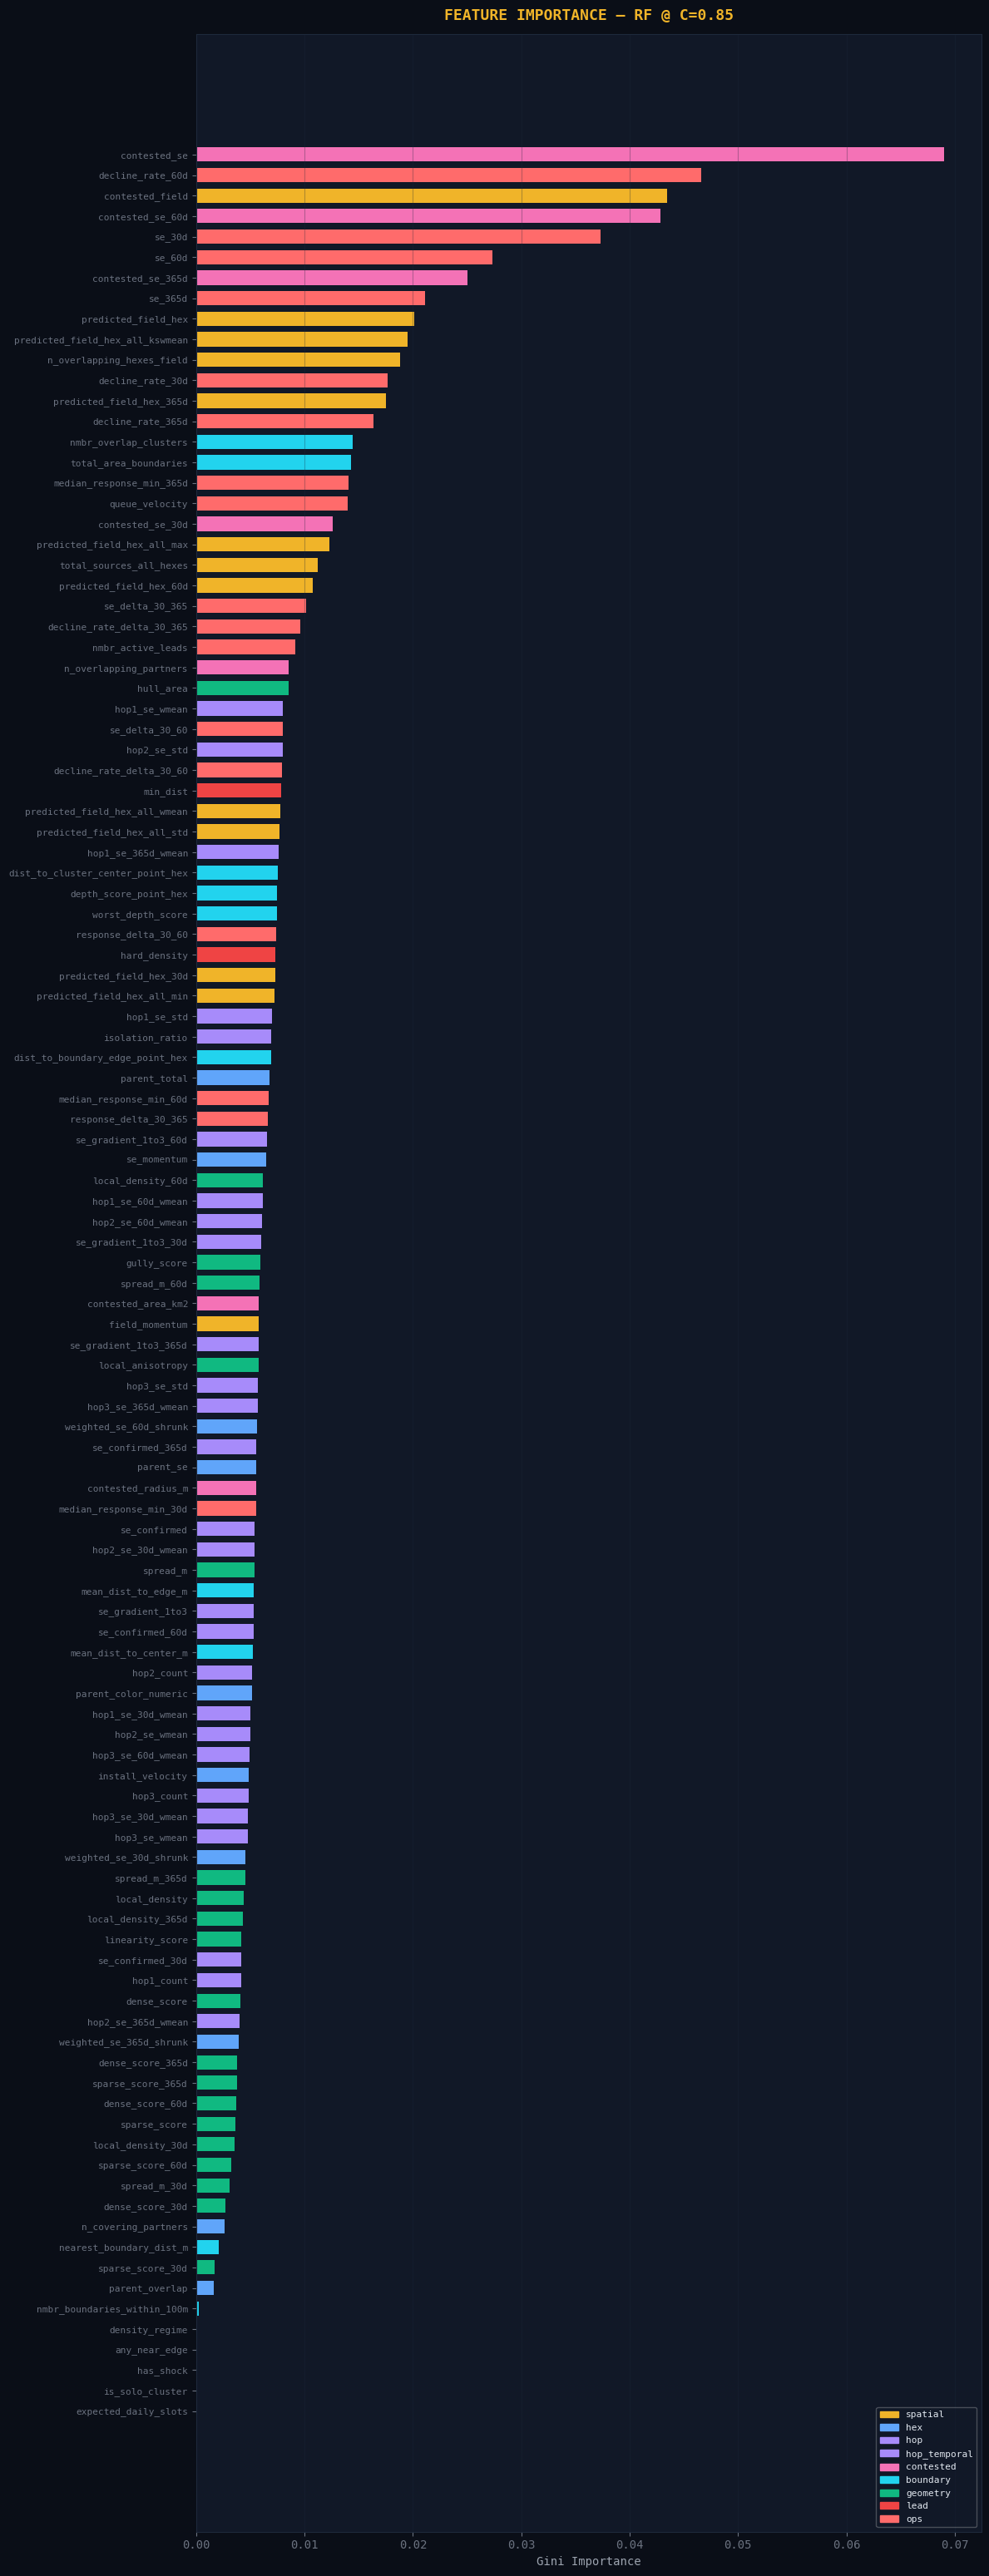

In [31]:
fig, ax = plt.subplots(figsize=(12, max(10, len(imp)*0.28)))
ax.barh(range(len(imp)), imp.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xlabel("Gini Importance")
ax.set_title(f"FEATURE IMPORTANCE — RF @ C={best_conc}", fontsize=13,
             fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)
patches = [mpatches.Patch(color=c, label=k) for k,c in fam_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3)
plt.tight_layout(); plt.show()


## 12 · Correlation & Collinearity


In [ ]:
feat_df = df_best[available + [TARGET]].dropna(subset=[TARGET])
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print("Top 15 correlated with target:")
for feat, val in corr_target.head(15).items():
    print(f"  {val:+.4f}  {feat}")


In [ ]:
# High collinearity pairs
corr_mx = feat_df[available].corr()
high_corr = []
for i in range(len(available)):
    for j in range(i+1, len(available)):
        r = corr_mx.iloc[i,j]
        if abs(r) > 0.7:
            high_corr.append((available[i], available[j], round(r,3)))
high_corr.sort(key=lambda x: -abs(x[2]))
print(f"\nHighly correlated pairs (|r|>0.7): {len(high_corr)}")
for a, b, r in high_corr[:20]:
    print(f"  {r:+.3f}  {a}  ↔  {b}")


### Importance vs Correlation


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for feat in imp.index:
    c = fam_colors.get(family_map.get(feat,""), GRAY)
    ax.scatter(corr_target.get(feat,0), imp[feat],
               c=c, s=60, alpha=0.85, edgecolor="white", lw=0.3, zorder=3)
for feat in imp.nlargest(10).index:
    if feat in corr_target.index:
        ax.annotate(feat, (corr_target[feat], imp[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5,5), textcoords="offset points")
ax.axvline(0, color=GRAY, ls="--", lw=0.8, alpha=0.5)
ax.set(xlabel="Pearson r with target", ylabel="RF Importance")
ax.set_title("IMPORTANCE vs CORRELATION", fontsize=11, fontweight="bold", color=AMBER)
ax.grid(alpha=0.2)
patches = [mpatches.Patch(color=c, label=k) for k,c in fam_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3)
plt.tight_layout(); plt.show()


## 13 · Saved Models


In [ ]:
print(f"{'Concordance':>12}  {'Model':>5}  {'Path'}")
print("-" * 60)
for (conc, tag), path in sorted(saved_models.items()):
    print(f"{conc:>12.2f}  {tag:>5}  {path}")
print(f"\nTotal models saved: {len(saved_models)}")
